# 02 — SQL Analysis

## Objective
Demonstrate SQL proficiency by querying the cleaned retail dataset using SQLite
inside Python. All queries run in-memory — no external database required.

## Techniques used
- Aggregations: SUM, COUNT, AVG, GROUP BY
- Filtering: WHERE, HAVING
- Sorting and ranking: ORDER BY, LIMIT
- Window functions: SUM() OVER(), cumulative distributions
- Date functions: STRFTIME for year-month and day-of-week extraction
- Subqueries: percentage of total revenue

## Key findings
| Metric | Value |
|---|---|
| Top country | United Kingdom (~84% of revenue) |
| Peak shopping day | Thursday |
| Top 20% customers | Generate ~77.2% of total revenue |
| Best performing month | November (holiday season) |



Imports & setup

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✓")

Libraries loaded ✓


Load clean data & create SQLite database

In [73]:
# Load the clean CSV we saved in notebook 01
df = pd.read_csv('../data/online_retail_clean.csv', parse_dates=['invoicedate'])

# Create an in-memory SQLite database and load the dataframe into it
conn = sqlite3.connect(':memory:')
df.to_sql('retail', conn, index=False, if_exists='replace')

print(f"Database created with {len(df):,} rows ✓")
print("Table name: retail")

Database created with 802,932 rows ✓
Table name: retail


Helper function

In [74]:
def query(sql):
    return pd.read_sql_query(sql, conn)

Explore the table structure

In [75]:
query("PRAGMA table_info(retail)")

,cid,name,type,notnull,dflt_value,pk
0,0,invoice,INTEGER,0,None,0
1,1,stockcode,TEXT,0,None,0
2,2,description,TEXT,0,None,0
3,3,quantity,INTEGER,0,None,0
4,4,invoicedate,TIMESTAMP,0,None,0
5,5,price,REAL,0,None,0
6,6,customer_id,INTEGER,0,None,0
7,7,country,TEXT,0,None,0
8,8,revenue,REAL,0,None,0


Total revenue, orders and customers

In [76]:
summary = query("""
    SELECT
        ROUND(SUM(revenue), 2)                          AS total_revenue,
        COUNT(DISTINCT invoice)                          AS total_orders,
        COUNT(DISTINCT customer_id)                      AS total_customers,
        ROUND(SUM(revenue) / COUNT(DISTINCT invoice), 2) AS avg_order_value,
        ROUND(SUM(revenue) / COUNT(DISTINCT customer_id), 2) AS avg_revenue_per_customer
    FROM retail
""")

summary

,total_revenue,total_orders,total_customers,avg_order_value,avg_revenue_per_customer
0,17451756.3,36645,5862,476.24,2977.1


Monthly revenue trend

In [77]:
monthly = query("""
    SELECT
        STRFTIME('%Y-%m', invoicedate)  AS month,
        ROUND(SUM(revenue), 2)          AS revenue,
        COUNT(DISTINCT invoice)         AS orders,
        COUNT(DISTINCT customer_id)     AS active_customers
    FROM retail
    GROUP BY month
    ORDER BY month 
""")

monthly

,month,revenue,orders,active_customers
0,2009-12,681529.72,1502,952
1,2010-01,539007.89,995,718
2,2010-02,499949.68,1093,771
3,2010-03,668977.19,1509,1051
4,2010-04,588126.27,1316,939
5,2010-05,595086.54,1365,965
6,2010-06,632685.90,1482,1035
7,2010-07,584048.53,1364,925
8,2010-08,597129.22,1276,910
9,2010-09,808545.06,1659,1136


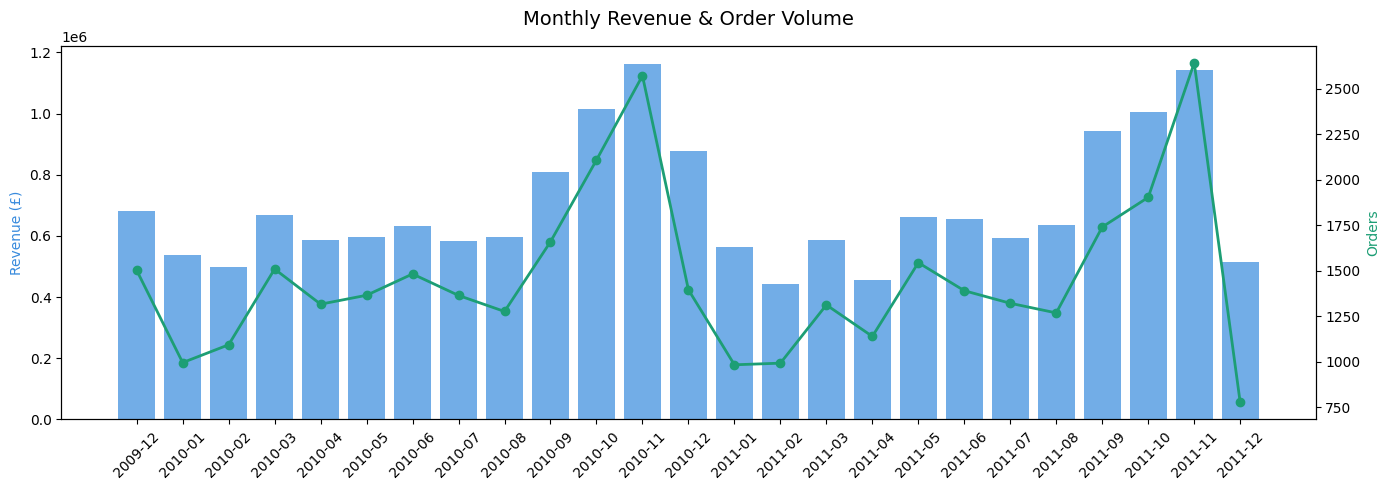

Chart saved ✓


In [78]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(monthly['month'], monthly['revenue'], color='#378ADD', alpha=0.7, label='Revenue')
ax1.set_ylabel('Revenue (£)', color='#378ADD')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['orders'], color='#1D9E75', marker='o', linewidth=2, label='Orders')
ax2.set_ylabel('Orders', color='#1D9E75')

plt.title('Monthly Revenue & Order Volume', fontsize=14, pad=15)
fig.tight_layout()
plt.savefig('../outputs/figures/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

Top 10 countries by revenue

In [79]:
countries = query("""
    SELECT
        country,
        ROUND(SUM(revenue), 2)      AS revenue,
        COUNT(DISTINCT invoice)     AS orders,
        COUNT(DISTINCT customer_id) AS customers,
        ROUND(SUM(revenue) * 100.0 / (SELECT SUM(revenue) FROM retail), 2) AS pct_of_total
    FROM retail
    GROUP BY country
    ORDER BY revenue DESC
    LIMIT 10
""")

countries

,country,revenue,orders,customers,pct_of_total
0,United Kingdom,14627419.25,33384,5336,83.82
1,Ireland,602058.00,542,5,3.45
2,Netherlands,549952.66,216,22,3.15
3,Germany,388959.99,756,107,2.23
4,France,315714.40,594,95,1.81
5,Australia,168484.66,89,15,0.97
6,Spain,98840.54,147,41,0.57
7,Switzerland,93624.34,82,22,0.54
8,Sweden,86079.04,98,19,0.49
9,Denmark,68560.19,42,12,0.39


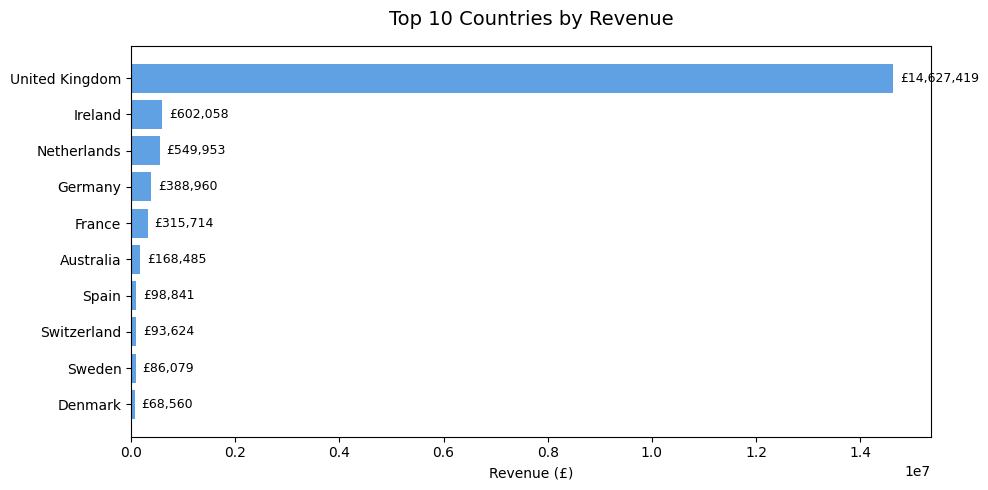

In [80]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(countries['country'][::-1], countries['revenue'][::-1], color='#378ADD', alpha=0.8)
ax.bar_label(bars, labels=[f"£{v:,.0f}" for v in countries['revenue'][::-1]], padding=5, fontsize=9)
ax.set_xlabel('Revenue (£)')
ax.set_title('Top 10 Countries by Revenue', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../outputs/figures/revenue_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

Top 10 products by revenue

In [81]:
products = query("""
    SELECT
        stockcode,
        description,
        ROUND(SUM(revenue), 2)  AS revenue,
        SUM(quantity)           AS units_sold,
        COUNT(DISTINCT invoice) AS orders
    FROM retail
    GROUP BY stockcode, description
    ORDER BY revenue DESC
    LIMIT 10
""")

products

,stockcode,description,revenue,units_sold,orders
0,22423,REGENCY CAKESTAND 3 TIER,286486.30,24899,3317
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,252072.46,93640,4888
2,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3,85099B,JUMBO BAG RED RETROSPOT,136980.08,75759,2612
4,84879,ASSORTED COLOUR BIRD ORNAMENT,127074.17,79913,2652
5,47566,PARTY BUNTING,103880.23,23607,2077
6,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195
7,22086,PAPER CHAIN KIT 50'S CHRISTMAS,79594.33,29477,1691
8,79321,CHILLI LIGHTS,72860.14,15735,922
9,21137,BLACK RECORD COVER FRAME,67209.44,19629,539


Revenue by day of week

In [82]:
dow = query("""
    SELECT
        CASE CAST(STRFTIME('%w', invoicedate) AS INTEGER)
            WHEN 0 THEN '0-Sun'
            WHEN 1 THEN '1-Mon'
            WHEN 2 THEN '2-Tue'
            WHEN 3 THEN '3-Wed'
            WHEN 4 THEN '4-Thu'
            WHEN 5 THEN '5-Fri'
            WHEN 6 THEN '6-Sat'
        END                         AS day_of_week,
        ROUND(SUM(revenue), 2)      AS revenue,
        COUNT(DISTINCT invoice)     AS orders
    FROM retail
    GROUP BY day_of_week
    ORDER BY day_of_week
""")

dow

,day_of_week,revenue,orders
0,0-Sun,1805946.52,4740
1,1-Mon,2751709.59,5691
2,2-Tue,3330081.40,6562
3,3-Wed,3076971.91,6597
4,4-Thu,3785820.98,7696
5,5-Fri,2691422.85,5329
6,6-Sat,9803.05,30


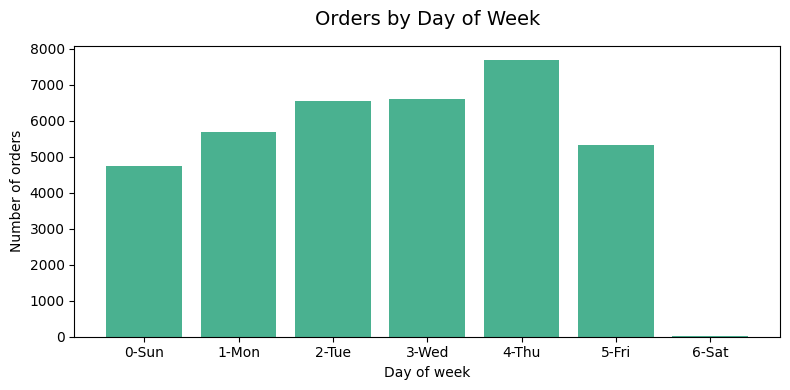

In [83]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow['day_of_week'], dow['orders'], color='#1D9E75', alpha=0.8)
ax.set_xlabel('Day of week')
ax.set_ylabel('Number of orders')
ax.set_title('Orders by Day of Week', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../outputs/figures/orders_by_dow.png', dpi=150, bbox_inches='tight')
plt.show()

Window functions: cumulative revenue

In [84]:
customer_revenue = query("""
    SELECT
        customer_id,
        ROUND(SUM(revenue), 2)  AS total_revenue,
        COUNT(DISTINCT invoice) AS total_orders,
        ROUND(SUM(revenue) * 100.0 / SUM(SUM(revenue)) OVER (), 2) AS pct_of_total,
        ROUND(SUM(SUM(revenue)) OVER (ORDER BY SUM(revenue) DESC) * 100.0
              / SUM(SUM(revenue)) OVER (), 2) AS cumulative_pct
    FROM retail
    GROUP BY customer_id
    ORDER BY total_revenue DESC
""")

# --- Top 10 customers preview ---
print("=== Top 10 Customers by Revenue ===")
display(customer_revenue.head(10))

# --- 80/20 hypothesis test ---
total_customers = len(customer_revenue)
top_20_cutoff  = int(total_customers * 0.20)
top_20         = customer_revenue.head(top_20_cutoff)
total_rev      = customer_revenue['total_revenue'].sum()
top_20_rev     = top_20['total_revenue'].sum()
revenue_share  = top_20_rev / total_rev * 100

print(f"\n=== 80/20 Hypothesis Test ===")
print(f"Total customers:               {total_customers:,}")
print(f"Top 20% threshold:             {top_20_cutoff:,} customers")
print(f"Revenue from top 20%:          £{top_20_rev:,.2f}")
print(f"Total dataset revenue:         £{total_rev:,.2f}")
print(f"Revenue share of top 20%:      {revenue_share:.1f}%")
print(f"\n→ Hypothesis {'CONFIRMED ✓' if revenue_share >= 60 else 'NOT confirmed — interesting finding!'}")
print(f"  Top 20% of customers generate {revenue_share:.0f}% of total revenue")

=== Top 10 Customers by Revenue ===


,customer_id,total_revenue,total_orders,pct_of_total,cumulative_pct
0,18102,608821.65,145,3.49,3.49
1,14646,526751.52,145,3.02,6.51
2,14156,305767.92,151,1.75,8.26
3,14911,284577.97,378,1.63,9.89
4,17450,246973.09,51,1.42,11.30
5,13694,196482.81,143,1.13,12.43
6,17511,175603.55,60,1.01,13.44
7,16446,168472.50,2,0.97,14.40
8,16684,147142.77,55,0.84,15.25
9,12415,144033.37,24,0.83,16.07



=== 80/20 Hypothesis Test ===
Total customers:               5,862
Top 20% threshold:             1,172 customers
Revenue from top 20%:          £13,472,473.89
Total dataset revenue:         £17,451,756.30
Revenue share of top 20%:      77.2%

→ Hypothesis CONFIRMED ✓
  Top 20% of customers generate 77% of total revenue


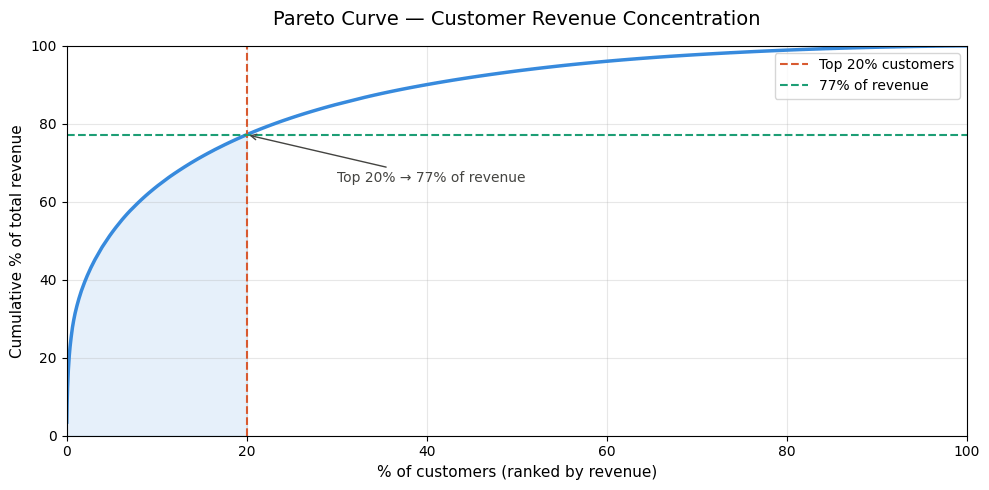

Pareto curve saved ✓


In [85]:
# --- Pareto curve ---
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(1, len(customer_revenue) + 1) / len(customer_revenue) * 100

ax.plot(x, customer_revenue['cumulative_pct'], color='#378ADD', linewidth=2.5)
ax.axvline(x=20, color='#D85A30', linestyle='--', linewidth=1.5, label='Top 20% customers')
ax.axhline(y=revenue_share, color='#1D9E75', linestyle='--', linewidth=1.5,
           label=f'{revenue_share:.0f}% of revenue')

ax.fill_between(x, customer_revenue['cumulative_pct'],
                where=(x <= 20), alpha=0.12, color='#378ADD')

ax.annotate(f"Top 20% → {revenue_share:.0f}% of revenue",
            xy=(20, revenue_share),
            xytext=(30, revenue_share - 12),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='#444441'),
            color='#444441')

ax.set_xlabel('% of customers (ranked by revenue)', fontsize=11)
ax.set_ylabel('Cumulative % of total revenue', fontsize=11)
ax.set_title('Pareto Curve — Customer Revenue Concentration', fontsize=14, pad=15)
ax.legend(fontsize=10)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/pareto_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Pareto curve saved ✓")

Return rate by country

In [86]:
aov_by_country = query("""
    SELECT
        country,
        COUNT(DISTINCT invoice)             AS total_orders,
        COUNT(DISTINCT customer_id)         AS total_customers,
        ROUND(SUM(revenue), 2)              AS total_revenue,
        ROUND(SUM(revenue) /
              COUNT(DISTINCT invoice), 2)   AS avg_order_value,
        ROUND(SUM(revenue) /
              COUNT(DISTINCT customer_id), 2) AS avg_revenue_per_customer
    FROM retail
    GROUP BY country
    HAVING total_orders > 50
    ORDER BY avg_order_value DESC
    LIMIT 10
""")

print("=== Average Order Value by Country (min. 50 orders) ===")
display(aov_by_country)

=== Average Order Value by Country (min. 50 orders) ===


,country,total_orders,total_customers,total_revenue,avg_order_value,avg_revenue_per_customer
0,Netherlands,216,22,549952.66,2546.08,24997.85
1,Australia,89,15,168484.66,1893.09,11232.31
2,Switzerland,82,22,93624.34,1141.76,4255.65
3,Ireland,542,5,602058.00,1110.81,120411.60
4,Sweden,98,19,86079.04,878.36,4530.48
5,Channel Islands,54,13,44703.76,827.85,3438.75
6,Spain,147,41,98840.54,672.38,2410.74
7,Portugal,84,24,48205.76,573.88,2008.57
8,France,594,95,315714.40,531.51,3323.31
9,Germany,756,107,388959.99,514.50,3635.14


In [87]:
# Reload raw data to calculate cancellation rate properly
df_raw = pd.read_csv('../data/raw/online_retail_II.xlsx') if False else pd.concat([
    pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2009-2010', engine='openpyxl'),
    pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2010-2011', engine='openpyxl')
], ignore_index=True)

df_raw.columns = df_raw.columns.str.strip().str.lower().str.replace(' ', '_')
df_raw['country'] = df_raw['country'].replace({'EIRE': 'Ireland'})

# Load into a second SQL table
df_raw.to_sql('retail_raw', conn, index=False, if_exists='replace')

cancellation_rate = query("""
    SELECT
        country,
        COUNT(DISTINCT invoice)                                      AS total_invoices,
        COUNT(DISTINCT CASE
            WHEN CAST(invoice AS TEXT) LIKE 'C%'
            THEN invoice END)                                        AS cancelled_invoices,
        ROUND(
            COUNT(DISTINCT CASE
                WHEN CAST(invoice AS TEXT) LIKE 'C%'
                THEN invoice END) * 100.0
            / COUNT(DISTINCT invoice), 2)                            AS cancellation_rate_pct
    FROM retail_raw
    WHERE country IS NOT NULL
    GROUP BY country
    HAVING total_invoices > 50
    ORDER BY cancellation_rate_pct DESC
    LIMIT 10
""")

print("=== Cancellation Rate by Country (min. 50 invoices) ===")
display(cancellation_rate)

=== Cancellation Rate by Country (min. 50 invoices) ===


,country,total_invoices,cancelled_invoices,cancellation_rate_pct
0,Japan,56,23,41.07
1,Channel Islands,79,24,30.38
2,Italy,92,27,29.35
3,Germany,1095,306,27.95
4,Switzerland,123,30,24.39
5,Portugal,124,29,23.39
6,Ireland,806,180,22.33
7,Denmark,53,10,18.87
8,Australia,117,22,18.80
9,Sweden,129,24,18.60


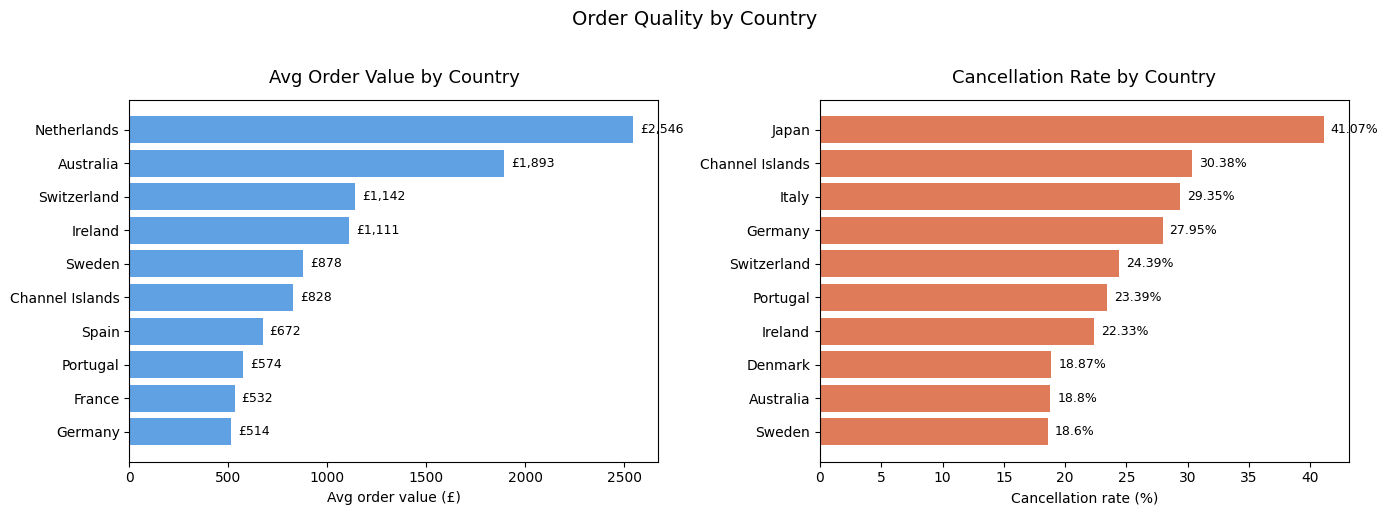

Chart saved ✓


In [88]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left — AOV by country
bars1 = ax1.barh(aov_by_country['country'][::-1],
                 aov_by_country['avg_order_value'][::-1],
                 color='#378ADD', alpha=0.8)
ax1.bar_label(bars1,
              labels=[f"£{v:,.0f}" for v in aov_by_country['avg_order_value'][::-1]],
              padding=5, fontsize=9)
ax1.set_xlabel('Avg order value (£)')
ax1.set_title('Avg Order Value by Country', fontsize=13, pad=12)

# Right — cancellation rate by country
bars2 = ax2.barh(cancellation_rate['country'][::-1],
                 cancellation_rate['cancellation_rate_pct'][::-1],
                 color='#D85A30', alpha=0.8)
ax2.bar_label(bars2,
              labels=[f"{v}%" for v in cancellation_rate['cancellation_rate_pct'][::-1]],
              padding=5, fontsize=9)
ax2.set_xlabel('Cancellation rate (%)')
ax2.set_title('Cancellation Rate by Country', fontsize=13, pad=12)

plt.suptitle('Order Quality by Country', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/order_quality_by_country.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")